# 2. Image segmentation to accurately delineate the regions of interest(U-net)

## This code mainly implements segmentation prediction using a pre-trained U-Net model (based on the EfficientNet-B3 encoder) on an image after the first step of denoising using pretzel noise and trof filter.

### Data loading and pre-processing

In [2]:
# Batch read data, fixed seed 24, divide dataset according to 80%
import os
from PIL import Image
import random

random.seed(24)

original_base_dir = '../../task 1 - Image denoising//EMDS5-Denoised-Trof'
gt_base_dir = '../../EMDS-6/EMDS5-Ground Truth'

data = []

subfolders = sorted(os.listdir(original_base_dir))

for folder in subfolders:
    original_folder = os.path.join(original_base_dir, folder)
    gt_folder = os.path.join(gt_base_dir, folder)
    if not os.path.isdir(original_folder) or not os.path.isdir(gt_folder):
        continue
    file_list = sorted([f for f in os.listdir(original_folder) if f.lower().endswith('.png')])
    for filename in file_list:
        orig_path = os.path.join(original_folder, filename)
        gt_filename = filename.replace(".png", "-GTM.png")
        gt_path = os.path.join(gt_folder, gt_filename)
        try:
            original_image = Image.open(orig_path).convert("RGB")
            gt_image = Image.open(gt_path).convert("L")
            data.append((original_image, gt_image))
        except Exception as e:
            print(f"{filename} error：", e)

print("Total image:", len(data))

random.shuffle(data)
train_ratio = 0.8
split_index = int(len(data) * train_ratio)
train_data = data[:split_index]
test_data = data[split_index:]

print("Train:", len(train_data))
print("Test:", len(test_data))

Total image: 840
Train: 672
Test: 168


In [3]:
# Save the dataset to train_data_spn.pkl and test_data_spn.pkl
import pickle

with open("train_data_spn.pkl", "wb") as f:
    pickle.dump(train_data, f)
with open("test_data_spn.pkl", "wb") as f:
    pickle.dump(test_data, f)

### Model definition and training

In [4]:
#In the training part, the images are unified as (512,512), and the pre-training model EfficientNet-B3 is used.
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

with open("train_data_spn.pkl", "rb") as f:
    train_data = pickle.load(f)

to_tensor_resize = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

train_data_tensor = [(to_tensor_resize(img), to_tensor_resize(mask)) for img, mask in train_data]
train_loader = DataLoader(train_data_tensor, batch_size=4, shuffle=True)
model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    avg_loss = total_loss / len(train_data_tensor)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "model-spn.pth")
print("Model save as model-spn.pth")

Epoch 1/100, Loss: 0.2007
Epoch 2/100, Loss: 0.1193
Epoch 3/100, Loss: 0.1075
Epoch 4/100, Loss: 0.0759
Epoch 5/100, Loss: 0.0738
Epoch 6/100, Loss: 0.0725
Epoch 7/100, Loss: 0.0672
Epoch 8/100, Loss: 0.0621
Epoch 9/100, Loss: 0.0550
Epoch 10/100, Loss: 0.0555
Epoch 11/100, Loss: 0.0598
Epoch 12/100, Loss: 0.0570
Epoch 13/100, Loss: 0.0549
Epoch 14/100, Loss: 0.0508
Epoch 15/100, Loss: 0.0452
Epoch 16/100, Loss: 0.0436
Epoch 17/100, Loss: 0.0415
Epoch 18/100, Loss: 0.0413
Epoch 19/100, Loss: 0.0391
Epoch 20/100, Loss: 0.0389
Epoch 21/100, Loss: 0.0693
Epoch 22/100, Loss: 0.0618
Epoch 23/100, Loss: 0.0501
Epoch 24/100, Loss: 0.0478
Epoch 25/100, Loss: 0.0420
Epoch 26/100, Loss: 0.0386
Epoch 27/100, Loss: 0.0366
Epoch 28/100, Loss: 0.0361
Epoch 29/100, Loss: 0.0396
Epoch 30/100, Loss: 0.0378
Epoch 31/100, Loss: 0.1014
Epoch 32/100, Loss: 0.0568
Epoch 33/100, Loss: 0.0436
Epoch 34/100, Loss: 0.0395
Epoch 35/100, Loss: 0.0375
Epoch 36/100, Loss: 0.0366
Epoch 37/100, Loss: 0.0340
Epoch 38/1

### Model Evaluation

In [1]:
import segmentation_models_pytorch as smp
import torch.nn.functional as F
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

with open("test_data_spn.pkl", "rb") as f:
    test_data = pickle.load(f)

to_tensor_resize = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

test_data_tensor = [(to_tensor_resize(img), to_tensor_resize(mask)) for img, mask in test_data]
test_loader = DataLoader(test_data_tensor, batch_size=4, shuffle=False)

model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = model.to(device)

model.load_state_dict(torch.load("model-spn.pth", weights_only=True))
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds_bin = (preds > 0.5).float()
        all_preds.append(preds_bin.cpu())
        all_labels.append(masks.cpu())
all_preds = torch.cat(all_preds, dim=0)
all_labels = torch.cat(all_labels, dim=0)

### Visualization of model evaluation

Average IoU: 85.27%
Lowest IoU: 18.07%
Highest IoU: 98.65%


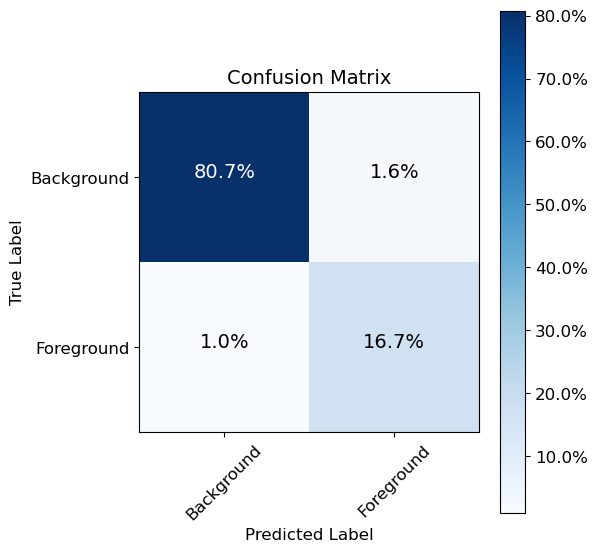

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import itertools

all_preds_flat = all_preds.view(-1).numpy().astype(int)
all_labels_flat = all_labels.view(-1).numpy().astype(int)
cm = confusion_matrix(all_labels_flat, all_preds_flat, labels=[0, 1])

iou_list = []
for i in range(all_preds.shape[0]):
    pred = all_preds[i]
    label = all_labels[i]
    intersection = (pred * label).sum().item()
    union = pred.sum().item() + label.sum().item() - intersection + 1e-6
    iou = intersection / union
    iou_list.append(iou)
iou_list = np.array(iou_list)
avg_iou = np.mean(iou_list)
min_iou = np.min(iou_list)
max_iou = np.max(iou_list)

print("Average IoU: {:.2f}%".format(avg_iou * 100))
print("Lowest IoU: {:.2f}%".format(min_iou * 100))
print("Highest IoU: {:.2f}%".format(max_iou * 100))

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    cm_sum = np.sum(cm)
    cm_percentage = cm / cm_sum * 100
    
    plt.figure(figsize=(6,6))
    plt.imshow(cm_percentage, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    cbar = plt.colorbar(format='%.1f%%')
    cbar.ax.tick_params(labelsize=12)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)
    thresh = cm_percentage.max() / 2.
    for i, j in itertools.product(range(cm_percentage.shape[0]), range(cm_percentage.shape[1])):
        plt.text(j, i, f"{cm_percentage[i, j]:.1f}%",
                 horizontalalignment="center",
                 color="white" if cm_percentage[i, j] > thresh else "black",
                 fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes=["Background", "Foreground"])

### Evaluation of calculating Dice coefficients and plotting confusion matrices

Average Dice: 91.33%
Lowest Dice: 30.61%
Highest Dice: 99.32%


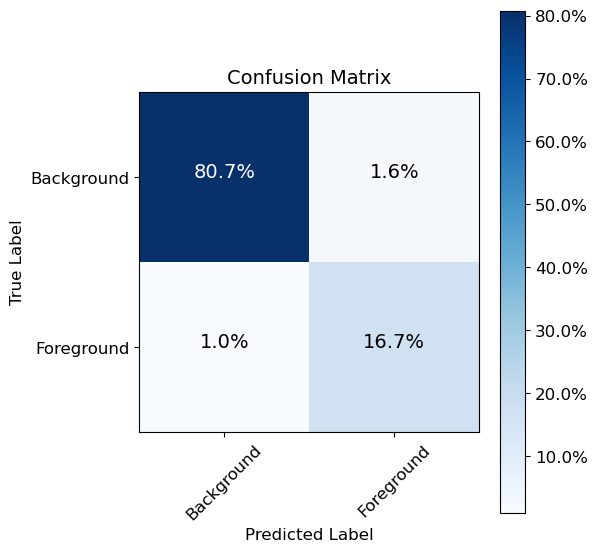

In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import itertools

all_preds_flat = all_preds.view(-1).numpy().astype(int)
all_labels_flat = all_labels.view(-1).numpy().astype(int)
cm = confusion_matrix(all_labels_flat, all_preds_flat, labels=[0, 1])

dice_list = []
eps = 1e-6
for i in range(all_preds.shape[0]):
    pred = all_preds[i]
    label = all_labels[i]
    intersection = (pred * label).sum().item()
    dice = 2 * intersection / (pred.sum().item() + label.sum().item() + eps)
    dice_list.append(dice)
dice_list = np.array(dice_list)
avg_dice = np.mean(dice_list)
min_dice = np.min(dice_list)
max_dice = np.max(dice_list)

print("Average Dice: {:.2f}%".format(avg_dice * 100))
print("Lowest Dice: {:.2f}%".format(min_dice * 100))
print("Highest Dice: {:.2f}%".format(max_dice * 100))

def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    cm_sum = np.sum(cm)
    cm_percentage = cm / cm_sum * 100

    plt.figure(figsize=(6,6))
    plt.imshow(cm_percentage, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=14)
    cbar = plt.colorbar(format='%.1f%%')
    cbar.ax.tick_params(labelsize=12)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)
    thresh = cm_percentage.max() / 2.
    for i, j in itertools.product(range(cm_percentage.shape[0]), range(cm_percentage.shape[1])):
        plt.text(j, i, f"{cm_percentage[i, j]:.1f}%",
                 horizontalalignment="center",
                 color="white" if cm_percentage[i, j] > thresh else "black",
                 fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes=["Background", "Foreground"])

### Calculation of multiple assessment metrics (Dice coefficient, Jaccard index and recall rate)

In [2]:
import numpy as np

eps = 1e-6

dice_list = []
jaccard_list = []
recall_list = []

for i in range(all_preds.shape[0]):
    pred = all_preds[i]
    label = all_labels[i]
    intersection = (pred * label).sum().item()
    dice = 2 * intersection / (pred.sum().item() + label.sum().item() + eps)
    jaccard = intersection / (pred.sum().item() + label.sum().item() - intersection + eps)
    recall = intersection / (label.sum().item() + eps)
    dice_list.append(dice)
    jaccard_list.append(jaccard)
    recall_list.append(recall)

dice_array = np.array(dice_list)
jaccard_array = np.array(jaccard_list)
recall_array = np.array(recall_list)

avg_dice = np.mean(dice_array)
min_dice = np.min(dice_array)
max_dice = np.max(dice_array)

avg_jaccard = np.mean(jaccard_array)
min_jaccard = np.min(jaccard_array)
max_jaccard = np.max(jaccard_array)

avg_recall = np.mean(recall_array)
min_recall = np.min(recall_array)
max_recall = np.max(recall_array)

print("Average Dice: {:.2f}%".format(avg_dice * 100))
print("Lowest Dice: {:.2f}%".format(min_dice * 100))
print("Highest Dice: {:.2f}%".format(max_dice * 100))
print()
print("Average Jaccard (IoU): {:.2f}%".format(avg_jaccard * 100))
print("Lowest Jaccard (IoU): {:.2f}%".format(min_jaccard * 100))
print("Highest Jaccard (IoU): {:.2f}%".format(max_jaccard * 100))
print()
print("Average Recall: {:.2f}%".format(avg_recall * 100))
print("Lowest Recall: {:.2f}%".format(min_recall * 100))
print("Highest Recall: {:.2f}%".format(max_recall * 100))


Average Dice: 91.33%
Lowest Dice: 30.61%
Highest Dice: 99.32%

Average Jaccard (IoU): 85.27%
Lowest Jaccard (IoU): 18.07%
Highest Jaccard (IoU): 98.65%

Average Recall: 90.98%
Lowest Recall: 45.83%
Highest Recall: 99.99%
